In [1]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI-ML/Data/Copy of FruitinAmazon.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [5]:
train_dir = "/content/data/FruitinAmazon/train"
test_dir = "/content/data/FruitinAmazon/test"

Classes found: ['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']


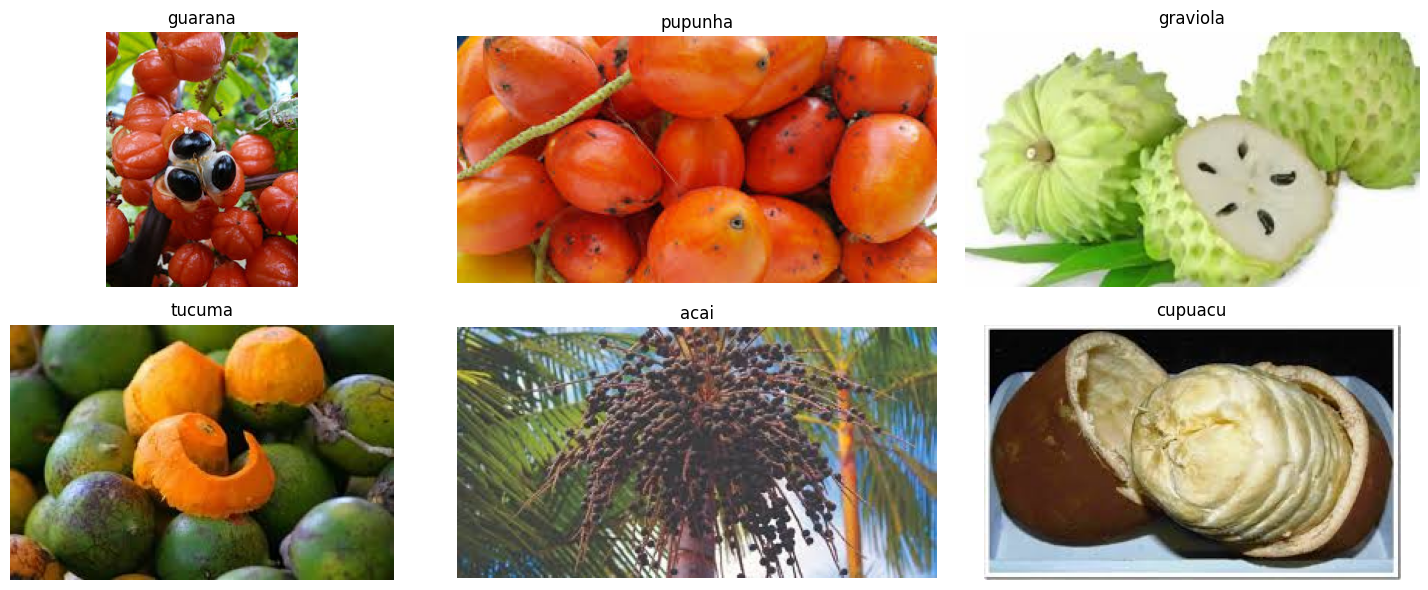

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


# Step 1: Get class directories
classes = [cls for cls in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, cls))]

print("Classes found:", classes)

# Step 2: Select one random image from each class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_files = os.listdir(class_path)

    # pick random image
    img_name = random.choice(img_files)
    img_path = os.path.join(class_path, img_name)

    images.append(img_path)
    labels.append(cls)

# Step 3: Display images in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2   # number of columns for 2 rows

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(images):
    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
import os
from PIL import Image

corrupted_images = []

# Iterate through each class folder
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        try:
            # Try opening and verifying image
            with Image.open(img_path) as img:
                img.verify()   # checks corruption without loading full image

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)

            # Remove corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final Output
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


In [24]:
import tensorflow as tf

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [25]:
from tensorflow.keras import layers,models
model = models.Sequential(
    [
        layers.Conv2D(32, (3, 3), activation='relu', padding = 'same', input_shape=(img_height, img_width, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding = 'same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(classes), activation='softmax')
    ]

)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

check_point = ModelCheckpoint(
    "model.h5",
    monitor = "val_accuracy",
    mode = "max",
)

early_stop = EarlyStopping(
    monitor = "val_loss",
    restore_best_weights = True,
    patience = 10
)

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size = 16,
    callbacks = [check_point,early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.2147 - loss: 1.8172

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 637ms/step - accuracy: 0.2222 - loss: 1.8542 - val_accuracy: 0.7778 - val_loss: 1.3908
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.3490 - loss: 1.6540

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.3750 - loss: 1.6302 - val_accuracy: 0.7778 - val_loss: 1.0977
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.4751 - loss: 1.3968

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 895ms/step - accuracy: 0.4722 - loss: 1.3735 - val_accuracy: 0.3889 - val_loss: 1.6671
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.4282 - loss: 1.2448

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 902ms/step - accuracy: 0.4722 - loss: 1.2001 - val_accuracy: 0.8333 - val_loss: 0.7964
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6719 - loss: 0.8980

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8333 - val_loss: 0.5293
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 1.0000 - loss: 0.0015

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 890ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8333 - val_loss: 0.4599
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 1.0000 - loss: 0.0012

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 875ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8333 - val_loss: 0.4201
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 1.0000 - loss: 0.0011

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 505ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.8333 - val_loss: 0.4056
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 1.0000 - loss: 8.1846e-04

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 1.0000 - loss: 8.5117e-04 - val_accuracy: 0.8333 - val_loss: 0.4034


In [29]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size= 32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))


loss, acc = model.evaluate(test_ds)
print(acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6333 - loss: 1.1281
0.6333333253860474


In [30]:
#save
model.save("final_model.h5")

from tensorflow.keras.models import load_model

model = load_model("final_model.h5")

#Re-evaluate
model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step - accuracy: 0.6333 - loss: 1.1281


[1.1280629634857178, 0.6333333253860474]

In [31]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
              precision    recall  f1-score   support

     guarana       0.67      0.80      0.73         5
     pupunha       0.50      0.60      0.55         5
    graviola       0.71      1.00      0.83         5
      tucuma       1.00      0.80      0.89         5
        acai       1.00      0.20      0.33         5
     cupuacu       0.33      0.40      0.36         5

    accuracy                           0.63        30
   macro avg       0.70      0.63      0.62        30
weighted avg       0.70      0.63      0.62        30



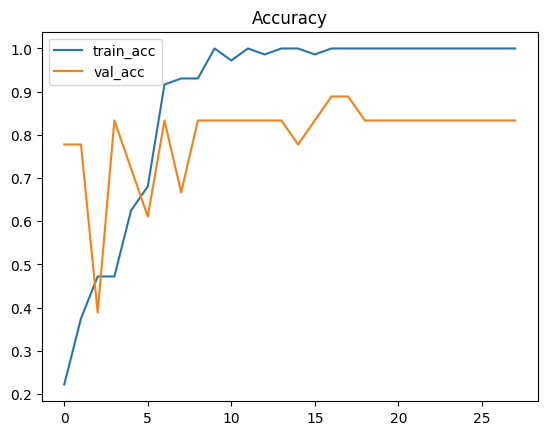

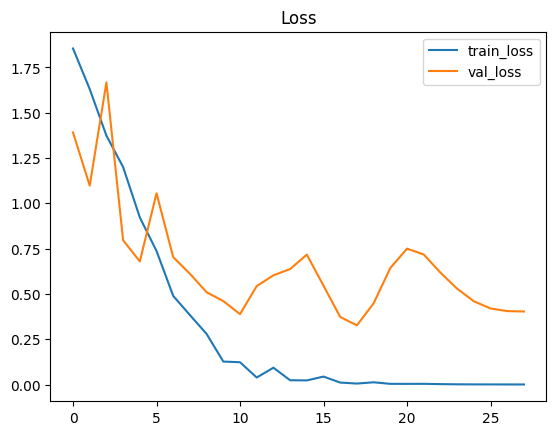

In [32]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()